In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
import sklearn

In [2]:
scaler = sklearn.preprocessing.StandardScaler()

In [3]:
df1 = pd.read_csv('/content/Buckeye_data.csv', skiprows = 1)
df2 = pd.read_csv('/content/Chandler_data.csv', skiprows = 1)
df3 = pd.read_csv('/content/Gilbert_data.csv', skiprows = 1)
df4 = pd.read_csv('/content/Goodyear_data.csv', skiprows = 1)
df5 = pd.read_csv('/content/Mesa_Business_data.csv', skiprows = 1)
df6 = pd.read_csv('/content/Phoenix_data.csv', skiprows = 1)
df7 = pd.read_csv('/content/Queen_Creek_Business.csv', skiprows = 1)
df8 = pd.read_csv('/content/Scottsdale_Business_Data.csv', skiprows = 1)
df9 = pd.read_csv('/content/Surprise_data.csv', skiprows = 1)
df10 = pd.read_csv('/content/Tempe_data.csv', skiprows = 1)

df = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10])

no_tempe = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9])

no_phx = pd.concat([df1, df2, df3, df4, df5, df7, df8, df9, df10])

df.head()

,Geographic identifier code,Geographic Area Name,2022 NAICS code,Meaning of NAICS code,Sex code,Meaning of Sex code,Ethnicity code,Meaning of Ethnicity code,Race code,Meaning of Race code,...,"Annual payroll ($1,000)",Percent of annual payroll (%),Relative standard error of employer firms (%),Standard error of percent of employer firms (%),"Relative standard error of sales, value of shipments, or revenue of employer firms (%)","Standard error of percent of sales, value of shipments, or revenue of employer firms (%)",Relative standard error of number of employees (%),Standard error of percent of employees (%),Relative standard error of annual payroll (%),Standard error of percent of annual payroll (%)
0,E600000US0401307940,"Buckeye city, Arizona",0,Total for all sectors,1,Total,1,Total,0,Total,...,276115,X,9,X,4.9,X,6,X,6.3,X
1,E600000US0401307940,"Buckeye city, Arizona",0,Total for all sectors,1,Total,1,Total,0,Total,...,17723,8.6,27,41,35.3,163.5,29.3,138,26.9,178.8
2,E600000US0401307940,"Buckeye city, Arizona",0,Total for all sectors,1,Total,1,Total,0,Total,...,11727,5.7,34.6,13.1,17.1,27.2,33.9,72.2,11.5,39.9
3,E600000US0401307940,"Buckeye city, Arizona",0,Total for all sectors,1,Total,1,Total,0,Total,...,135096,65.7,14.6,1.2,5.1,1.4,6.3,1.9,6.6,1.6
4,E600000US0401307940,"Buckeye city, Arizona",0,Total for all sectors,1,Total,1,Total,0,Total,...,13399,6.5,6.3,0.4,4,0.4,0.9,0.4,0.7,0.3


In [4]:
df = df[df['Sales, value of shipments, or revenue of employer firms ($1,000)'] != 'All firms']
df = df[df['Sales, value of shipments, or revenue of employer firms ($1,000)'] != 'All firms']
df = df[df['Percent of employer firms (%)'] != 'X']
df = df[df['Percent of employer firms (%)'] != 'S']
df = df.apply(pd.to_numeric, errors = 'ignore')
df = df.drop(columns = ['2022 NAICS code', 'Sex code', 'Ethnicity code', 'Race code', 'Veteran code', 'Meaning of NAICS code','Meaning of Sex code','Meaning of Ethnicity code','Meaning of Race code','Meaning of Veteran code'])

no_tempe = no_tempe[no_tempe['Sales, value of shipments, or revenue of employer firms ($1,000)'] != 'All firms']
no_tempe = no_tempe[no_tempe['Sales, value of shipments, or revenue of employer firms ($1,000)'] != 'All firms']
no_tempe = no_tempe[no_tempe['Percent of employer firms (%)'] != 'X']
no_tempe = no_tempe[no_tempe['Percent of employer firms (%)'] != 'S']
no_tempe = no_tempe.apply(pd.to_numeric, errors = 'ignore')
no_tempe = no_tempe.drop(columns = ['2022 NAICS code', 'Sex code', 'Ethnicity code', 'Race code', 'Veteran code', 'Meaning of NAICS code','Meaning of Sex code','Meaning of Ethnicity code','Meaning of Race code','Meaning of Veteran code'])

no_phx = no_phx[no_phx['Sales, value of shipments, or revenue of employer firms ($1,000)'] != 'All firms']
no_phx = no_phx[no_phx['Sales, value of shipments, or revenue of employer firms ($1,000)'] != 'All firms']
no_phx = no_phx[no_phx['Percent of employer firms (%)'] != 'X']
no_phx = no_phx[no_phx['Percent of employer firms (%)'] != 'S']
no_phx = no_phx.apply(pd.to_numeric, errors = 'ignore')
no_phx = no_phx.drop(columns = ['2022 NAICS code', 'Sex code', 'Ethnicity code', 'Race code', 'Veteran code', 'Meaning of NAICS code','Meaning of Sex code','Meaning of Ethnicity code','Meaning of Race code','Meaning of Veteran code'])

/tmp/ipykernel_2687/3816890150.py:5: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors = 'ignore')
/tmp/ipykernel_2687/3816890150.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  no_tempe = no_tempe.apply(pd.to_numeric, errors = 'ignore')
/tmp/ipykernel_2687/3816890150.py:19: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  no_phx = no_phx.apply(pd.to_numeric, errors = 'ignore')


In [26]:
df.shape

(662, 23)

In [5]:
df.describe()

,Year,Number of employer firms,Percent of employer firms (%),"Sales, value of shipments, or revenue of employer firms ($1,000)","Percent of sales, value of shipments, or revenue of employer firms (%)",Number of employees,Percent of employees (%),"Annual payroll ($1,000)",Percent of annual payroll (%),Relative standard error of employer firms (%),Standard error of percent of employer firms (%),"Relative standard error of sales, value of shipments, or revenue of employer firms (%)","Standard error of percent of sales, value of shipments, or revenue of employer firms (%)",Relative standard error of number of employees (%),Standard error of percent of employees (%),Relative standard error of annual payroll (%),Standard error of percent of annual payroll (%)
count,662.0,662.000000,662.000000,6.620000e+02,662.000000,662.000000,662.000000,6.620000e+02,662.000000,662.000000,662.000000,662.000000,662.000000,662.000000,662.000000,662.000000,662.000000
mean,2022.0,984.783988,33.602870,1.189018e+07,37.759517,29808.716012,37.424622,1.913560e+06,37.716616,18.343051,5.377341,7.750453,19.990785,9.051057,17.438218,8.496375,17.395166
std,0.0,2160.987579,36.622869,3.005681e+07,37.578863,71777.214945,37.501472,4.688914e+06,37.678962,13.885692,6.709255,8.242752,27.043273,9.868562,24.702491,8.768741,24.096231
min,2022.0,2.000000,0.100000,3.231000e+03,0.000000,11.000000,0.000000,5.280000e+02,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000
25%,2022.0,55.250000,4.700000,3.758380e+05,5.925000,1553.500000,5.800000,7.098300e+04,5.900000,8.900000,0.800000,2.800000,1.225000,3.400000,1.400000,3.400000,1.300000
50%,2022.0,218.500000,12.300000,1.902495e+06,19.750000,6089.500000,18.350000,3.002320e+05,18.350000,14.100000,2.650000,4.700000,9.300000,5.700000,8.300000,5.600000,8.600000
75%,2022.0,811.000000,58.900000,7.466389e+06,76.900000,24498.500000,74.100000,1.238430e+06,76.150000,23.875000,7.500000,9.250000,26.100000,10.500000,20.100000,9.900000,22.500000
max,2022.0,13858.000000,100.000000,2.058129e+08,100.000000,489852.000000,100.000000,3.209125e+07,100.000000,71.200000,44.200000,46.900000,167.300000,70.900000,147.700000,55.900000,178.800000


In [6]:
no_tempe.describe()

,Year,Number of employer firms,Percent of employer firms (%),"Sales, value of shipments, or revenue of employer firms ($1,000)","Percent of sales, value of shipments, or revenue of employer firms (%)",Number of employees,Percent of employees (%),"Annual payroll ($1,000)",Percent of annual payroll (%),Relative standard error of employer firms (%),Standard error of percent of employer firms (%),"Relative standard error of sales, value of shipments, or revenue of employer firms (%)","Standard error of percent of sales, value of shipments, or revenue of employer firms (%)",Relative standard error of number of employees (%),Standard error of percent of employees (%),Relative standard error of annual payroll (%),Standard error of percent of annual payroll (%)
count,592.0,592.000000,592.000000,5.920000e+02,592.000000,592.000000,592.000000,5.920000e+02,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000,592.000000
mean,2022.0,1010.822635,33.688851,1.158380e+07,37.986824,29339.498311,37.608446,1.882166e+06,37.929730,18.708615,5.367061,8.027703,20.206081,9.506588,17.866047,8.922297,17.770439
std,0.0,2263.279004,36.685505,3.121028e+07,37.539431,74725.295598,37.565475,4.882879e+06,37.739163,14.107965,6.757660,8.472213,27.488595,10.157425,25.377138,8.986373,24.788054
min,2022.0,2.000000,0.100000,3.231000e+03,0.000000,11.000000,0.000000,5.280000e+02,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000
25%,2022.0,50.750000,4.675000,3.250510e+05,6.175000,1275.750000,5.775000,5.863050e+04,5.850000,9.100000,0.700000,2.900000,1.100000,3.600000,1.300000,3.700000,1.150000
50%,2022.0,211.500000,12.200000,1.826307e+06,19.800000,5488.000000,18.650000,2.595115e+05,18.500000,14.450000,2.650000,4.900000,9.350000,5.800000,8.350000,5.700000,8.600000
75%,2022.0,772.500000,59.100000,7.159161e+06,76.300000,22859.000000,74.525000,1.187033e+06,76.650000,24.525000,7.500000,10.100000,26.225000,11.150000,20.250000,10.525000,22.625000
max,2022.0,13858.000000,100.000000,2.058129e+08,100.000000,489852.000000,100.000000,3.209125e+07,100.000000,71.200000,44.200000,46.900000,167.300000,70.900000,147.700000,55.900000,178.800000


In [7]:
no_phx.describe()

,Year,Number of employer firms,Percent of employer firms (%),"Sales, value of shipments, or revenue of employer firms ($1,000)","Percent of sales, value of shipments, or revenue of employer firms (%)",Number of employees,Percent of employees (%),"Annual payroll ($1,000)",Percent of annual payroll (%),Relative standard error of employer firms (%),Standard error of percent of employer firms (%),"Relative standard error of sales, value of shipments, or revenue of employer firms (%)","Standard error of percent of sales, value of shipments, or revenue of employer firms (%)",Relative standard error of number of employees (%),Standard error of percent of employees (%),Relative standard error of annual payroll (%),Standard error of percent of annual payroll (%)
count,591.0,591.000000,591.00000,5.910000e+02,591.000000,591.000000,591.000000,5.910000e+02,591.000000,591.000000,591.000000,591.000000,591.000000,591.000000,591.000000,591.000000,591.000000
mean,2022.0,620.972927,33.81709,6.018444e+06,37.914552,15629.505922,37.612352,9.935006e+05,37.906261,19.581726,5.595601,8.166159,20.159391,9.625212,17.726565,8.960575,17.658714
std,0.0,1050.380906,36.66322,1.124222e+07,37.643678,25715.457722,37.600547,1.815669e+06,37.788615,14.019524,6.918936,8.396580,27.451645,10.118306,25.148198,8.917909,24.602210
min,2022.0,2.000000,0.10000,3.231000e+03,0.000000,11.000000,0.000000,5.280000e+02,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000
25%,2022.0,47.000000,4.70000,3.104890e+05,5.750000,1247.500000,5.700000,5.697500e+04,5.550000,9.700000,0.800000,3.000000,1.150000,3.800000,1.250000,3.700000,1.200000
50%,2022.0,162.000000,12.50000,1.529664e+06,20.400000,4738.000000,18.900000,2.327230e+05,18.700000,15.600000,3.000000,5.000000,8.700000,5.900000,8.600000,5.700000,8.500000
75%,2022.0,654.000000,59.20000,5.916936e+06,76.600000,17543.000000,74.550000,1.024079e+06,76.800000,25.700000,7.900000,10.150000,26.600000,11.200000,20.450000,10.500000,22.850000
max,2022.0,5683.000000,100.00000,5.252886e+07,100.000000,112077.000000,100.000000,7.627874e+06,100.000000,71.200000,44.200000,46.900000,167.300000,70.900000,147.700000,55.900000,178.800000


Text(0, 0.5, 'Frequency')

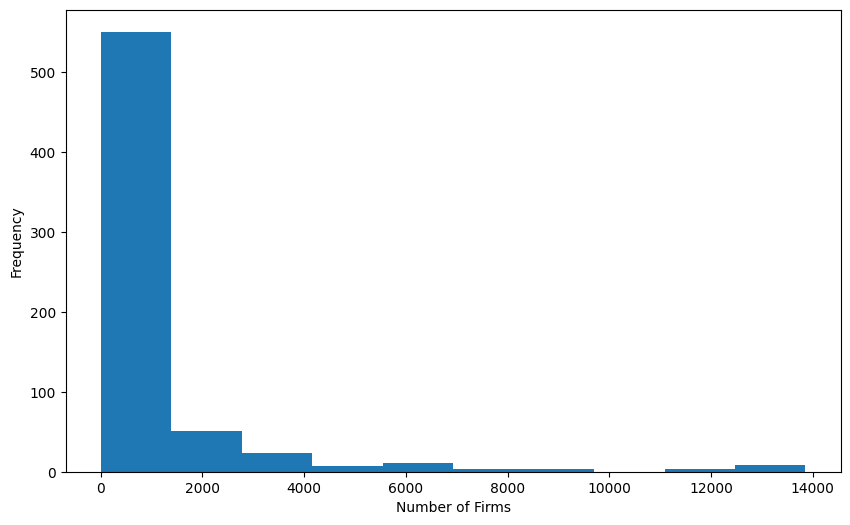

In [8]:
plt.pyplot.figure(figsize=(10, 6))
plt.pyplot.hist(df['Number of employer firms'])

plt.pyplot.xlabel('Number of Firms')
plt.pyplot.ylabel('Frequency')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70],
 [Text(0, 0, 'BQ'),
  Text(1, 0, 'BQ01'),
  Text(2, 0, 'BQ03'),
  Text(3, 0, 'BQ04'),
  Text(4, 0, 'BX'),
  Text(5, 0, 'BY'),
  Text(6, 0, 'BM'),
  Text(7, 0, 'BN'),
  Text(8, 0, 'BO'),
  Text(9, 0, 'MA'),
  Text(10, 0, 'MC'),
  Text(11, 0, 'MD'),
  Text(12, 0, 'LV'),
  Text(13, 0, 'LW'),
  Text(14, 0, 'LX'),
  Text(15, 0, 'IB'),
  Text(16, 0, 'IC'),
  Text(17, 0, 'ID01'),
  Text(18, 0, 'ID02'),
  Text(19, 0, 'IE'),
  Text(20, 0, 'IE01'),
  Text(21, 0, 'IF'),
  Text(22, 0, 'JT'),
  Text(23, 0, 'JU'),
  Text(24, 0, 'JV'),
  Text(25, 0, 'JW'),
  Text(26, 0, 'JX'),
  Text(27, 0, 

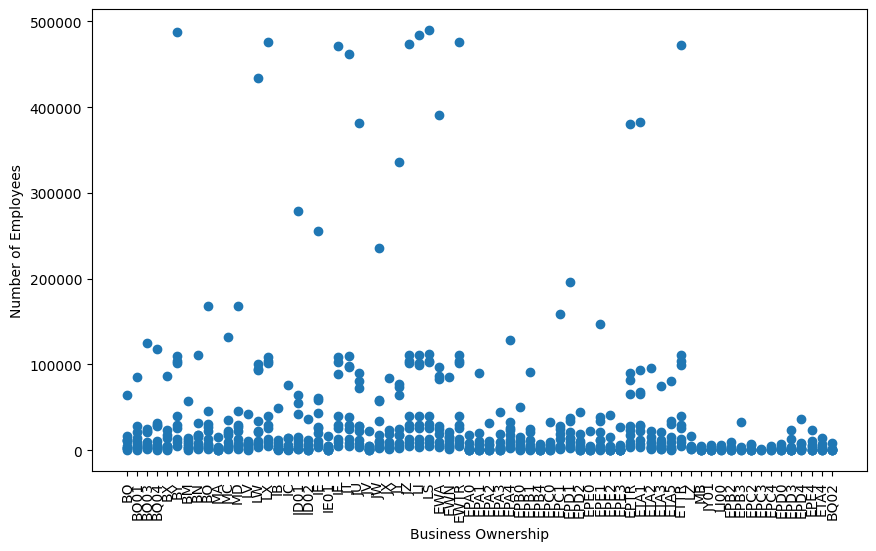

In [9]:
plt.pyplot.figure(figsize=(10, 6))

plt.pyplot.scatter(df['Business characteristic code'], df['Number of employees'])
plt.pyplot.xlabel("Business Ownership")
plt.pyplot.ylabel("Number of Employees")
plt.pyplot.xticks(rotation=90)

In [10]:
encoder = sklearn.preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(df[['Geographic identifier code', 'Business characteristic code']])

numerical_cols_to_scale = df.select_dtypes(include=np.number).drop(columns=['Year'], errors='ignore').columns
scaled_numerical_features = scaler.fit_transform(df[numerical_cols_to_scale])

encoded_features_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['Geographic identifier code', 'Business characteristic code']), index=df.index)
scaled_numerical_features_df = pd.DataFrame(scaled_numerical_features, columns=numerical_cols_to_scale, index=df.index)

test_df = pd.concat([scaled_numerical_features_df, encoded_features_df], axis=1)

In [11]:
X = test_df.drop(columns=['Sales, value of shipments, or revenue of employer firms ($1,000)'])
y = test_df['Sales, value of shipments, or revenue of employer firms ($1,000)']

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=1)

In [12]:
model = sklearn.tree.DecisionTreeRegressor(random_state=10)
model.fit(X_train, y_train)

print('R2 Score:', model.score(X_train,y_train))


R2 Score: 1.0


In [13]:
model_score = model.score(X_test, y_test)

print('Training R2 Score:', model.score(X_train,y_train))
print("Test R2 Score:", model_score)

Training R2 Score: 1.0
Test R2 Score: 0.9679538166908924


In [14]:
importances = model.feature_importances_

feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

top_predictors = feature_importance_df.sort_values(by='Importance', ascending=False)
top_predictors.head()

,Feature,Importance
5,"Annual payroll ($1,000)",0.950589
13,Relative standard error of annual payroll (%),0.024029
3,Number of employees,0.009478
10,"Standard error of percent of sales, value of s...",0.004506
6,Percent of annual payroll (%),0.004370


In [15]:
encoder = sklearn.preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(no_tempe[['Geographic identifier code', 'Business characteristic code']])

numerical_cols_to_scale = no_tempe.select_dtypes(include=np.number).drop(columns=['Year'], errors='ignore').columns
scaled_numerical_features = scaler.fit_transform(no_tempe[numerical_cols_to_scale])

encoded_features_no_tempe = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['Geographic identifier code', 'Business characteristic code']), index=no_tempe.index)
scaled_numerical_features_no_tempe = pd.DataFrame(scaled_numerical_features, columns=numerical_cols_to_scale, index=no_tempe.index)

test_no_tempe = pd.concat([scaled_numerical_features_no_tempe, encoded_features_no_tempe], axis=1)

In [16]:
X = test_no_tempe.drop(columns=['Sales, value of shipments, or revenue of employer firms ($1,000)'])
y = test_no_tempe['Sales, value of shipments, or revenue of employer firms ($1,000)']

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=1)

In [17]:
model = sklearn.tree.DecisionTreeRegressor(random_state=10)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=10)

In [18]:
model_score = model.score(X_test, y_test)

print('Training R2 Score:', model.score(X_train,y_train))
print("Test R2 Score:", model_score)

Training R2 Score: 1.0
Test R2 Score: 0.9725933189390402


In [19]:
importances = model.feature_importances_

feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

top_predictors = feature_importance_df.sort_values(by='Importance', ascending=False)
top_predictors.head()

,Feature,Importance
3,Number of employees,0.856384
5,"Annual payroll ($1,000)",0.098939
4,Percent of employees (%),0.029291
13,Relative standard error of annual payroll (%),0.005465
7,Relative standard error of employer firms (%),0.004920


In [20]:
encoder = sklearn.preprocessing.OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_features = encoder.fit_transform(no_phx[['Geographic identifier code', 'Business characteristic code']])

numerical_cols_to_scale = no_phx.select_dtypes(include=np.number).drop(columns=['Year'], errors='ignore').columns
scaled_numerical_features = scaler.fit_transform(no_phx[numerical_cols_to_scale])

encoded_features_no_phx = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['Geographic identifier code', 'Business characteristic code']), index=no_phx.index)
scaled_numerical_features_no_phx = pd.DataFrame(scaled_numerical_features, columns=numerical_cols_to_scale, index=no_phx.index)

test_no_phx = pd.concat([scaled_numerical_features_no_phx, encoded_features_no_phx], axis=1)

In [21]:
X = test_no_phx.drop(columns=['Sales, value of shipments, or revenue of employer firms ($1,000)'])
y = test_no_phx['Sales, value of shipments, or revenue of employer firms ($1,000)']

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=1)

In [22]:
model = sklearn.tree.DecisionTreeRegressor(random_state=10)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=10)

In [23]:
model_score = model.score(X_test, y_test)

print('Training R2 Score:', model.score(X_train,y_train))
print("Test R2 Score:", model_score)

Training R2 Score: 1.0
Test R2 Score: 0.9708078261634852


In [24]:
importances = model.feature_importances_

feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

top_predictors = feature_importance_df.sort_values(by='Importance', ascending=False)
top_predictors.head()

,Feature,Importance
3,Number of employees,0.819356
5,"Annual payroll ($1,000)",0.130376
13,Relative standard error of annual payroll (%),0.031219
0,Number of employer firms,0.004405
77,Business characteristic code_JU,0.003049
